In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/Hackthon/dataset_A_training.csv")
test = pd.read_csv("/content/drive/MyDrive/Hackthon/dataset_A_testing.csv")

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

train.head()

Training shape: (4756, 31)
Testing shape: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [10]:
print("Training columns:")
print(train.columns.tolist())

print("\nTarget column present in training:")
print("seasonal_vaccine" in train.columns)

print("\nTarget column present in testing:")
print("seasonal_vaccine" in test.columns)

print("\nDuplicate rows in training:", train.duplicated().sum())
print("Duplicate rows in testing:", test.duplicated().sum())

print("\nTarget value counts:")
print(train["seasonal_vaccine"].value_counts())

print("\nTarget percentages:")
print((train["seasonal_vaccine"].value_counts(normalize=True) * 100).round(2))

Training columns:
['respondent_id', 'flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'household_adults', 'household_children', 'employment_sector', 'seasonal_vaccine']

Target column present in training:
True

Target column present in testing:
False

Duplicate rows in training: 0
Duplicate rows in testing: 0

Target value counts:
seasonal_vaccine
1    2551
0    2205
Name: count, dtype: int64

Target percentages:
seasonal_vaccine
1    53.64
0    46.36
Name: proportion, dtype: float64


In [11]:
missing = train.isnull().sum().sort_values(ascending=False)

print("Missing values in training data:\n")
print(missing[missing > 0])

print("\nTotal columns with missing values:", (missing > 0).sum())

Missing values in training data:

employment_sector              2314
health_insurance               1925
income_poverty                  790
rent_or_own                     381
doctor_recc_seasonal            321
education                       270
employment_status               269
marital_status                  265
chronic_med_condition           188
child_under_6_months            152
health_worker                   149
opinion_seas_risk               102
opinion_seas_sick_from_vacc     101
opinion_seas_vacc_effective      94
household_children               44
household_adults                 44
behavioral_avoidance             32
flu_knowledge                    23
behavioral_touch_face            19
behavioral_antiviral_meds        14
flu_concern                      12
behavioral_large_gatherings       9
behavioral_outside_home           9
behavioral_wash_hands             8
behavioral_face_mask              3
dtype: int64

Total columns with missing values: 25


In [13]:
target = "seasonal_vaccine"
id_col = "respondent_id"

X = train.drop(columns=[target, id_col])
y = train[target]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical columns:")
print(numerical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))

Categorical columns:
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']

Number of categorical columns: 10

Numerical columns:
['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']

Number of numerical columns: 19


In [15]:
train_features = train.drop(columns=["seasonal_vaccine"])

print("Number of training features:", train_features.shape[1])
print("Number of testing features:", test.shape[1])

print("\nColumns only in training:")
print(sorted(set(train_features.columns) - set(test.columns)))

print("\nColumns only in testing:")
print(sorted(set(test.columns) - set(train_features.columns)))

print("\nSame column order:")
print(train_features.columns.tolist() == test.columns.tolist())

Number of training features: 30
Number of testing features: 30

Columns only in training:
[]

Columns only in testing:
[]

Same column order:
True


In [16]:
missing_summary = (
    train.isnull()
    .sum()
    .to_frame(name="missing_count")
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(train) * 100
).round(2)

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    by="missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
employment_sector,2314,48.65
health_insurance,1925,40.48
income_poverty,790,16.61
rent_or_own,381,8.01
doctor_recc_seasonal,321,6.75
education,270,5.68
employment_status,269,5.66
marital_status,265,5.57
chronic_med_condition,188,3.95
child_under_6_months,152,3.20


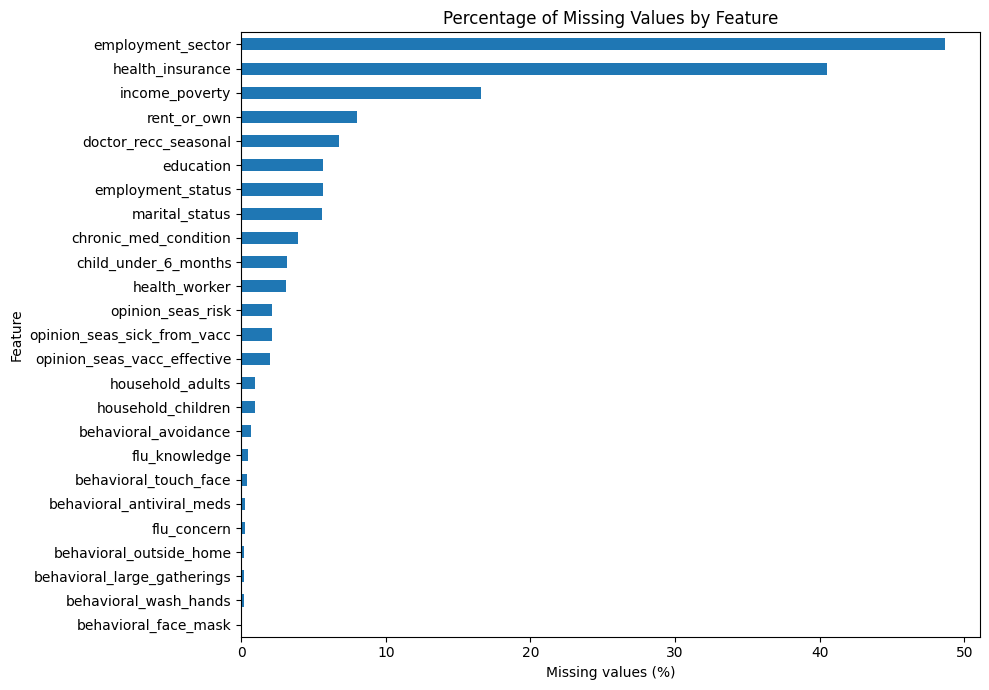

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

missing_summary["missing_percentage"].sort_values().plot(
    kind="barh"
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

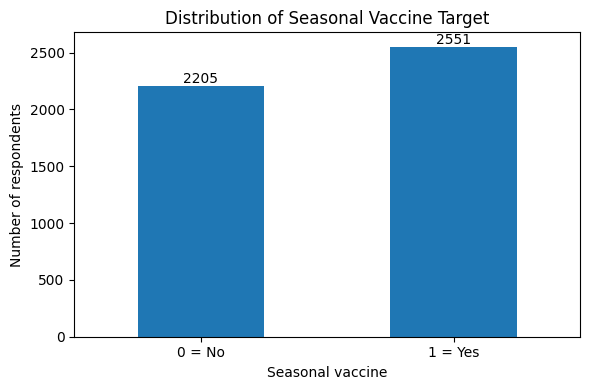

In [18]:
import matplotlib.pyplot as plt

target_counts = train["seasonal_vaccine"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")

plt.title("Distribution of Seasonal Vaccine Target")
plt.xlabel("Seasonal vaccine")
plt.ylabel("Number of respondents")
plt.xticks(
    ticks=[0, 1],
    labels=["0 = No", "1 = Yes"],
    rotation=0
)

for index, value in enumerate(target_counts):
    plt.text(index, value + 25, str(value), ha="center")

plt.tight_layout()
plt.show()

In [19]:
for col in categorical_cols:
    print("\n" + "=" * 60)
    print(f"Column: {col}")
    print("Unique values:", train[col].nunique(dropna=False))
    print(train[col].value_counts(dropna=False))


Column: age_group
Unique values: 5
age_group
65+ Years        1169
55 - 64 Years     999
18 - 34 Years     960
45 - 54 Years     931
35 - 44 Years     697
Name: count, dtype: int64

Column: education
Unique values: 5
education
College Graduate    1879
Some College        1209
12 Years             992
< 12 Years           406
NaN                  270
Name: count, dtype: int64

Column: race
Unique values: 4
race
White                3766
Black                 362
Other or Multiple     317
Hispanic              311
Name: count, dtype: int64

Column: sex
Unique values: 2
sex
Female    2783
Male      1973
Name: count, dtype: int64

Column: income_poverty
Unique values: 4
income_poverty
<= $75,000, Above Poverty    2258
> $75,000                    1250
NaN                           790
Below Poverty                 458
Name: count, dtype: int64

Column: marital_status
Unique values: 3
marital_status
Married        2403
Not Married    2088
NaN             265
Name: count, dtype: int64

Colu

In [20]:
numerical_summary = train[numerical_cols].describe().T

numerical_summary["missing_count"] = train[numerical_cols].isnull().sum()
numerical_summary["missing_percentage"] = (
    train[numerical_cols].isnull().sum() / len(train) * 100
).round(2)

numerical_summary

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage
flu_concern,4744.0,1.643128,0.919810,0.0,1.0,2.0,2.0,3.0,12,0.25
flu_knowledge,4733.0,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0,23,0.48
behavioral_antiviral_meds,4742.0,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0,14,0.29
behavioral_avoidance,4724.0,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0,32,0.67
behavioral_face_mask,4753.0,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0,3,0.06
behavioral_wash_hands,4748.0,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0,8,0.17
behavioral_large_gatherings,4747.0,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0,9,0.19
behavioral_outside_home,4747.0,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0,9,0.19
behavioral_touch_face,4737.0,0.688410,0.463192,0.0,0.0,1.0,1.0,1.0,19,0.40
doctor_recc_seasonal,4435.0,0.373619,0.483819,0.0,0.0,0.0,1.0,1.0,321,6.75


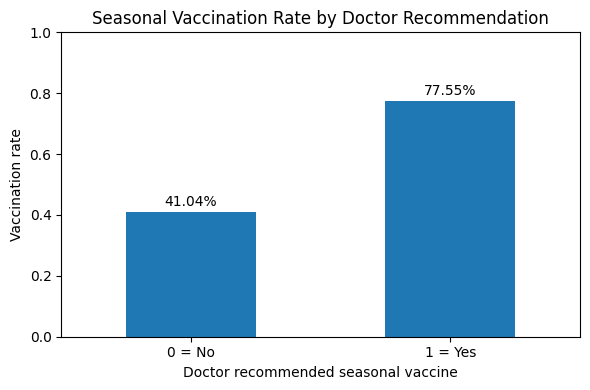

doctor_recc_seasonal
0.0    0.410367
1.0    0.775498
Name: seasonal_vaccine, dtype: float64


In [21]:
import matplotlib.pyplot as plt

doctor_recommendation_rate = (
    train.groupby("doctor_recc_seasonal")["seasonal_vaccine"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(6, 4))
doctor_recommendation_rate.plot(kind="bar")

plt.title("Seasonal Vaccination Rate by Doctor Recommendation")
plt.xlabel("Doctor recommended seasonal vaccine")
plt.ylabel("Vaccination rate")
plt.xticks(
    ticks=[0, 1],
    labels=["0 = No", "1 = Yes"],
    rotation=0
)
plt.ylim(0, 1)

for index, value in enumerate(doctor_recommendation_rate):
    plt.text(index, value + 0.02, f"{value:.2%}", ha="center")

plt.tight_layout()
plt.show()

print(doctor_recommendation_rate)

In [22]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=["seasonal_vaccine", "respondent_id"])
y = train["seasonal_vaccine"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

print("\nTraining target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation target percentages:")
print((y_valid.value_counts(normalize=True) * 100).round(2))

X_train shape: (3804, 29)
X_valid shape: (952, 29)

Training target percentages:
seasonal_vaccine
1    53.63
0    46.37
Name: proportion, dtype: float64

Validation target percentages:
seasonal_vaccine
1    53.68
0    46.32
Name: proportion, dtype: float64


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_cols),
        ("categorical", categorical_pipeline, categorical_cols)
    ]
)

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))
print("Preprocessing pipeline created successfully.")

Numerical columns: 19
Categorical columns: 10
Preprocessing pipeline created successfully.


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

y_valid_pred = baseline_model.predict(X_valid)
y_valid_prob = baseline_model.predict_proba(X_valid)[:, 1]

print("Baseline Logistic Regression Results")
print("-" * 45)
print("Accuracy :", round(accuracy_score(y_valid, y_valid_pred), 4))
print("Precision:", round(precision_score(y_valid, y_valid_pred), 4))
print("Recall   :", round(recall_score(y_valid, y_valid_pred), 4))
print("F1 Score :", round(f1_score(y_valid, y_valid_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_valid, y_valid_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, y_valid_pred))

print("\nClassification Report:")
print(classification_report(y_valid, y_valid_pred))

Baseline Logistic Regression Results
---------------------------------------------
Accuracy : 0.7826
Precision: 0.8016
Recall   : 0.7906
F1 Score : 0.7961
ROC-AUC  : 0.8474

Confusion Matrix:
[[341 100]
 [107 404]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77       441
           1       0.80      0.79      0.80       511

    accuracy                           0.78       952
   macro avg       0.78      0.78      0.78       952
weighted avg       0.78      0.78      0.78       952



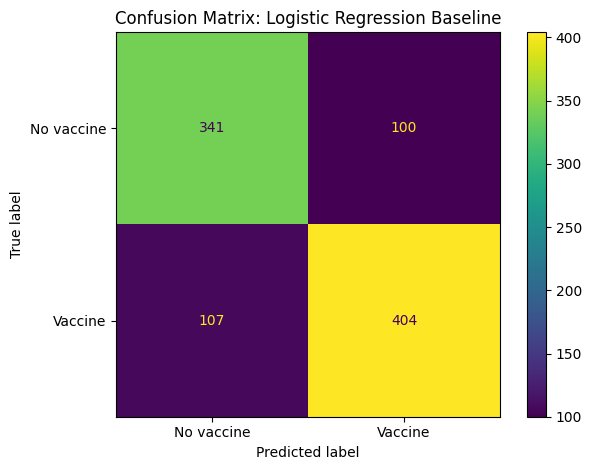

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred,
    display_labels=["No vaccine", "Vaccine"]
)

plt.title("Confusion Matrix: Logistic Regression Baseline")
plt.tight_layout()
plt.show()

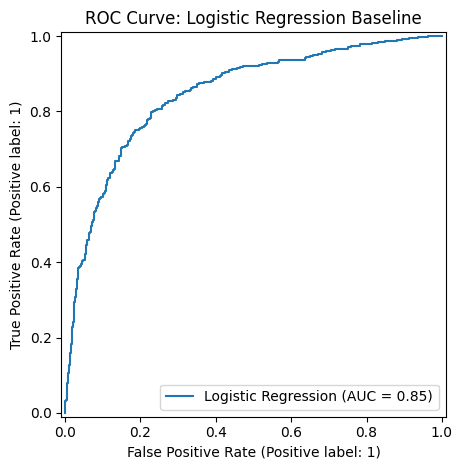

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_valid,
    y_valid_prob,
    name="Logistic Regression"
)

plt.title("ROC Curve: Logistic Regression Baseline")
plt.tight_layout()
plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_valid_pred = random_forest_model.predict(X_valid)
rf_valid_prob = random_forest_model.predict_proba(X_valid)[:, 1]

print("Random Forest Results")
print("-" * 45)
print("Accuracy :", round(accuracy_score(y_valid, rf_valid_pred), 4))
print("Precision:", round(precision_score(y_valid, rf_valid_pred), 4))
print("Recall   :", round(recall_score(y_valid, rf_valid_pred), 4))
print("F1 Score :", round(f1_score(y_valid, rf_valid_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_valid, rf_valid_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, rf_valid_pred))

Random Forest Results
---------------------------------------------
Accuracy : 0.771
Precision: 0.7812
Recall   : 0.7965
F1 Score : 0.7888
ROC-AUC  : 0.844

Confusion Matrix:
[[327 114]
 [104 407]]


In [29]:
import pandas as pd

model_results = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest"
        ],
        "Accuracy": [
            accuracy_score(y_valid, y_valid_pred),
            accuracy_score(y_valid, rf_valid_pred)
        ],
        "Precision": [
            precision_score(y_valid, y_valid_pred),
            precision_score(y_valid, rf_valid_pred)
        ],
        "Recall": [
            recall_score(y_valid, y_valid_pred),
            recall_score(y_valid, rf_valid_pred)
        ],
        "F1 Score": [
            f1_score(y_valid, y_valid_pred),
            f1_score(y_valid, rf_valid_pred)
        ],
        "ROC-AUC": [
            roc_auc_score(y_valid, y_valid_prob),
            roc_auc_score(y_valid, rf_valid_prob)
        ]
    }
)

model_results = model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7826,0.8016,0.7906,0.7961,0.8474
1,Random Forest,0.7710,0.7812,0.7965,0.7888,0.8440


In [30]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder

# Gradient Boosting requires dense encoded features
categorical_pipeline_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

dense_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_pipeline, numerical_cols),
        ("categorical", categorical_pipeline_dense, categorical_cols)
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)

gb_valid_pred = gradient_boosting_model.predict(X_valid)
gb_valid_prob = gradient_boosting_model.predict_proba(X_valid)[:, 1]

print("Gradient Boosting Results")
print("-" * 45)
print("Accuracy :", round(accuracy_score(y_valid, gb_valid_pred), 4))
print("Precision:", round(precision_score(y_valid, gb_valid_pred), 4))
print("Recall   :", round(recall_score(y_valid, gb_valid_pred), 4))
print("F1 Score :", round(f1_score(y_valid, gb_valid_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_valid, gb_valid_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, gb_valid_pred))

Gradient Boosting Results
---------------------------------------------
Accuracy : 0.7878
Precision: 0.7988
Recall   : 0.8082
F1 Score : 0.8035
ROC-AUC  : 0.8528

Confusion Matrix:
[[337 104]
 [ 98 413]]


In [31]:
# Prepare the hidden testing dataset
X_test = test.drop(columns=["respondent_id"])

# Train the model again using all available training rows
gradient_boosting_model.fit(X, y)

# Generate predictions for the testing dataset
gb_test_predictions = gradient_boosting_model.predict(X_test)

# Create the submission file
submission_1 = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": gb_test_predictions
})

# Save the CSV file in your Google Drive Hackathon folder
submission_1.to_csv(
    "/content/drive/MyDrive/Hackathon/1_gradient_boosting.csv",
    index=False
)

print("CSV created successfully.")
print("Shape:", submission_1.shape)

print("\nPrediction counts:")
print(submission_1["seasonal_vaccine"].value_counts())

submission_1.head()

CSV created successfully.
Shape: (4749, 2)

Prediction counts:
seasonal_vaccine
1    2714
0    2035
Name: count, dtype: int64


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [32]:
# Train Logistic Regression using the full training dataset
baseline_model.fit(X, y)

# Generate predictions for the hidden testing dataset
lr_test_predictions = baseline_model.predict(X_test)

# Create the second submission file
submission_2 = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": lr_test_predictions
})

# Save the CSV file
submission_2.to_csv(
    "/content/drive/MyDrive/Hackathon/2_logistic_regression.csv",
    index=False
)

print("CSV 2 created successfully.")
print("Shape:", submission_2.shape)

print("\nPrediction counts:")
print(submission_2["seasonal_vaccine"].value_counts())

submission_2.head()

CSV 2 created successfully.
Shape: (4749, 2)

Prediction counts:
seasonal_vaccine
1    2681
0    2068
Name: count, dtype: int64


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [33]:
# Train Random Forest using the full training dataset
random_forest_model.fit(X, y)

# Generate predictions for the hidden testing dataset
rf_test_predictions = random_forest_model.predict(X_test)

# Create the third submission file
submission_3 = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": rf_test_predictions
})

# Save the CSV file
submission_3.to_csv(
    "/content/drive/MyDrive/Hackathon/3_random_forest.csv",
    index=False
)

print("CSV 3 created successfully.")
print("Shape:", submission_3.shape)

print("\nPrediction counts:")
print(submission_3["seasonal_vaccine"].value_counts())

submission_3.head()

CSV 3 created successfully.
Shape: (4749, 2)

Prediction counts:
seasonal_vaccine
1    2696
0    2053
Name: count, dtype: int64


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [34]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

extra_trees_model.fit(X_train, y_train)

et_valid_pred = extra_trees_model.predict(X_valid)
et_valid_prob = extra_trees_model.predict_proba(X_valid)[:, 1]

print("Extra Trees Results")
print("-" * 45)
print("Accuracy :", round(accuracy_score(y_valid, et_valid_pred), 4))
print("Precision:", round(precision_score(y_valid, et_valid_pred), 4))
print("Recall   :", round(recall_score(y_valid, et_valid_pred), 4))
print("F1 Score :", round(f1_score(y_valid, et_valid_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_valid, et_valid_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, et_valid_pred))

Extra Trees Results
---------------------------------------------
Accuracy : 0.7637
Precision: 0.7771
Recall   : 0.7847
F1 Score : 0.7809
ROC-AUC  : 0.8393

Confusion Matrix:
[[326 115]
 [110 401]]


In [36]:
# Train Extra Trees using the full training dataset
extra_trees_model.fit(X, y)

# Generate predictions for the hidden testing dataset
et_test_predictions = extra_trees_model.predict(X_test)

# Create the fourth submission file
submission_4 = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": et_test_predictions
})

# Save the CSV file
submission_4.to_csv(
    "/content/drive/MyDrive/Hackathon/4_extra_trees.csv",
    index=False
)

print("CSV 4 created successfully.")
print("Shape:", submission_4.shape)

print("\nPrediction counts:")
print(submission_4["seasonal_vaccine"].value_counts())

submission_4.head()

CSV 4 created successfully.
Shape: (4749, 2)

Prediction counts:
seasonal_vaccine
1    2741
0    2008
Name: count, dtype: int64


,respondent_id,seasonal_vaccine
0,4757,1
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [37]:
from sklearn.ensemble import GradientBoostingClassifier

tuned_gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", dense_preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=250,
                learning_rate=0.03,
                max_depth=2,
                min_samples_leaf=8,
                subsample=0.9,
                random_state=42
            )
        )
    ]
)

tuned_gradient_boosting_model.fit(X_train, y_train)

tuned_gb_valid_pred = tuned_gradient_boosting_model.predict(X_valid)
tuned_gb_valid_prob = tuned_gradient_boosting_model.predict_proba(X_valid)[:, 1]

print("Tuned Gradient Boosting Results")
print("-" * 45)
print("Accuracy :", round(accuracy_score(y_valid, tuned_gb_valid_pred), 4))
print("Precision:", round(precision_score(y_valid, tuned_gb_valid_pred), 4))
print("Recall   :", round(recall_score(y_valid, tuned_gb_valid_pred), 4))
print("F1 Score :", round(f1_score(y_valid, tuned_gb_valid_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_valid, tuned_gb_valid_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, tuned_gb_valid_pred))

Tuned Gradient Boosting Results
---------------------------------------------
Accuracy : 0.7794
Precision: 0.7945
Recall   : 0.7945
F1 Score : 0.7945
ROC-AUC  : 0.8526

Confusion Matrix:
[[336 105]
 [105 406]]


In [38]:
# Train the tuned Gradient Boosting model using the full training dataset
tuned_gradient_boosting_model.fit(X, y)

# Generate predictions for the hidden testing dataset
tuned_gb_test_predictions = tuned_gradient_boosting_model.predict(X_test)

# Create the fifth submission file
submission_5 = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": tuned_gb_test_predictions
})

# Save the CSV file
submission_5.to_csv(
    "/content/drive/MyDrive/Hackathon/5_tuned_gradient_boosting.csv",
    index=False
)

print("CSV 5 created successfully.")
print("Shape:", submission_5.shape)

print("\nPrediction counts:")
print(submission_5["seasonal_vaccine"].value_counts())

submission_5.head()

CSV 5 created successfully.
Shape: (4749, 2)

Prediction counts:
seasonal_vaccine
1    2693
0    2056
Name: count, dtype: int64


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [39]:
import os

final_folder = "/content/drive/MyDrive/Hackathon/final_ranked_submissions"
os.makedirs(final_folder, exist_ok=True)

# Rank models from best to worst using validation ROC-AUC
final_submissions = {
    "1_gradient_boosting.csv": submission_1,
    "2_tuned_gradient_boosting.csv": submission_5,
    "3_logistic_regression.csv": submission_2,
    "4_random_forest.csv": submission_3,
    "5_extra_trees.csv": submission_4
}

for filename, submission in final_submissions.items():
    file_path = os.path.join(final_folder, filename)
    submission.to_csv(file_path, index=False)
    print(f"Saved: {filename} | Shape: {submission.shape}")

print("\nFinal ranked files saved in:")
print(final_folder)

Saved: 1_gradient_boosting.csv | Shape: (4749, 2)
Saved: 2_tuned_gradient_boosting.csv | Shape: (4749, 2)
Saved: 3_logistic_regression.csv | Shape: (4749, 2)
Saved: 4_random_forest.csv | Shape: (4749, 2)
Saved: 5_extra_trees.csv | Shape: (4749, 2)

Final ranked files saved in:
/content/drive/MyDrive/Hackathon/final_ranked_submissions


In [40]:
import os
import pandas as pd

final_folder = "/content/drive/MyDrive/Hackathon/final_ranked_submissions"

expected_columns = ["respondent_id", "seasonal_vaccine"]
expected_rows = len(test)

files = sorted([
    filename
    for filename in os.listdir(final_folder)
    if filename.endswith(".csv")
])

print("Checking final ranked CSV files...\n")

all_predictions = {}

for filename in files:
    file_path = os.path.join(final_folder, filename)
    df = pd.read_csv(file_path)

    print("=" * 70)
    print("File:", filename)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:", int(df.isnull().sum().sum()))
    print("Duplicate respondent IDs:", int(df["respondent_id"].duplicated().sum()))
    print("Valid prediction values:", sorted(df["seasonal_vaccine"].unique().tolist()))

    checks = {
        "Correct number of rows": len(df) == expected_rows,
        "Correct columns": df.columns.tolist() == expected_columns,
        "No missing values": df.isnull().sum().sum() == 0,
        "No duplicate respondent IDs": df["respondent_id"].duplicated().sum() == 0,
        "IDs match testing data": df["respondent_id"].equals(
            test["respondent_id"].reset_index(drop=True)
        ),
        "Predictions contain only 0 and 1": set(
            df["seasonal_vaccine"].unique()
        ).issubset({0, 1})
    }

    for check_name, passed in checks.items():
        print(f"{check_name}: {'PASS' if passed else 'FAIL'}")

    all_predictions[filename] = df["seasonal_vaccine"]

print("\n" + "=" * 70)
print("Pairwise differences between prediction files:\n")

for i in range(len(files)):
    for j in range(i + 1, len(files)):
        differences = (
            all_predictions[files[i]] != all_predictions[files[j]]
        ).sum()

        print(f"{files[i]} vs {files[j]}: {differences} different predictions")

Checking final ranked CSV files...

File: 1_gradient_boosting.csv
Shape: (4749, 2)
Columns: ['respondent_id', 'seasonal_vaccine']
Missing values: 0
Duplicate respondent IDs: 0
Valid prediction values: [0, 1]
Correct number of rows: PASS
Correct columns: PASS
No missing values: PASS
No duplicate respondent IDs: PASS
IDs match testing data: PASS
Predictions contain only 0 and 1: PASS
File: 2_tuned_gradient_boosting.csv
Shape: (4749, 2)
Columns: ['respondent_id', 'seasonal_vaccine']
Missing values: 0
Duplicate respondent IDs: 0
Valid prediction values: [0, 1]
Correct number of rows: PASS
Correct columns: PASS
No missing values: PASS
No duplicate respondent IDs: PASS
IDs match testing data: PASS
Predictions contain only 0 and 1: PASS
File: 3_logistic_regression.csv
Shape: (4749, 2)
Columns: ['respondent_id', 'seasonal_vaccine']
Missing values: 0
Duplicate respondent IDs: 0
Valid prediction values: [0, 1]
Correct number of rows: PASS
Correct columns: PASS
No missing values: PASS
No duplicat